# STDA Assignment A3: Task 2 and Task 4

This notebook uses the already-cleaned 2024 NYC TLC Yellow Taxi parquet files in `dataset/`.

- **Task 2:** Temporal feature engineering and machine learning for hourly demand forecasting.
- **Task 4:** Temporal data mining using contiguous state sequence mining and a Markov next-state model.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("dataset")
OUTPUT_DIR = Path("task2_task4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_PATH = Path("temporal_hourly_2024.parquet")

MONTH_ORDER = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}

parquet_files = sorted(
    DATA_DIR.glob("clean_*.parquet"),
    key=lambda path: MONTH_ORDER[path.stem.split("_")[1]],
)

print(f"Found {len(parquet_files)} cleaned monthly parquet files.")
print([path.name for path in parquet_files])


Found 12 cleaned monthly parquet files.
['clean_jan.parquet', 'clean_feb.parquet', 'clean_mar.parquet', 'clean_apr.parquet', 'clean_may.parquet', 'clean_jun.parquet', 'clean_jul.parquet', 'clean_aug.parquet', 'clean_sep.parquet', 'clean_oct.parquet', 'clean_nov.parquet', 'clean_dec.parquet']


## Build Hourly Temporal Dataset

The raw cleaned files contain trip-level data. For temporal modelling, the target is hourly taxi demand (`trip_count`). Trip behavior features are aggregated per hour using count-weighted sums, then converted into hourly means.


In [2]:
def build_hourly_cache(files, cache_path):
    if cache_path.exists():
        hourly = pd.read_parquet(cache_path)
        hourly.index = pd.to_datetime(hourly.index)
        hourly.index.name = "pickup_hour"
        print(f"Loaded cached hourly aggregate: {cache_path}")
        return hourly

    columns = [
        "pickup_time", "trip_distance", "fare_amount", "total_amount",
        "passenger_count", "trip_duration", "speed",
    ]
    parts = []
    total_rows = 0

    for path in files:
        df = pd.read_parquet(path, columns=columns)
        df = df[
            (df["pickup_time"] >= pd.Timestamp("2024-01-01"))
            & (df["pickup_time"] < pd.Timestamp("2025-01-01"))
        ].copy()
        total_rows += len(df)
        df["pickup_hour"] = df["pickup_time"].dt.floor("h")

        grouped = df.groupby("pickup_hour").agg(
            trip_count=("pickup_hour", "size"),
            distance_sum=("trip_distance", "sum"),
            fare_sum=("fare_amount", "sum"),
            total_sum=("total_amount", "sum"),
            passengers_sum=("passenger_count", "sum"),
            duration_sum=("trip_duration", "sum"),
            speed_sum=("speed", "sum"),
        )
        parts.append(grouped)
        print(f"{path.name}: {len(df):,} rows -> {len(grouped):,} hourly bins")

    raw_hourly = pd.concat(parts).groupby(level=0).sum(numeric_only=True).sort_index()

    full_index = pd.date_range("2024-01-01 00:00:00", "2024-12-31 23:00:00", freq="h")
    hourly = raw_hourly.reindex(full_index)
    hourly.index.name = "pickup_hour"
    missing_hours = hourly["trip_count"].isna().sum()
    if missing_hours:
        print("Interpolating missing hourly bins:", hourly[hourly["trip_count"].isna()].index.tolist())

    hourly["trip_count"] = hourly["trip_count"].interpolate().round().astype(int)
    for col in ["distance_sum", "fare_sum", "total_sum", "passengers_sum", "duration_sum", "speed_sum"]:
        hourly[col] = hourly[col].interpolate()

    hourly["mean_distance"] = hourly["distance_sum"] / hourly["trip_count"]
    hourly["mean_fare"] = hourly["fare_sum"] / hourly["trip_count"]
    hourly["mean_total"] = hourly["total_sum"] / hourly["trip_count"]
    hourly["mean_passengers"] = hourly["passengers_sum"] / hourly["trip_count"]
    hourly["mean_duration"] = hourly["duration_sum"] / hourly["trip_count"]
    hourly["mean_speed"] = hourly["speed_sum"] / hourly["trip_count"]

    keep_cols = [
        "trip_count", "mean_distance", "mean_fare", "mean_total",
        "mean_passengers", "mean_duration", "mean_speed",
    ]
    hourly = hourly[keep_cols]
    hourly.to_parquet(cache_path)
    print(f"Cached {len(hourly):,} hourly rows from {total_rows:,} trips at {cache_path}.")
    return hourly


hourly = build_hourly_cache(parquet_files, CACHE_PATH)
display(hourly.head())
display(hourly.tail())
hourly.describe().round(2)


Loaded cached hourly aggregate: temporal_hourly_2024.parquet


,trip_count,mean_distance,mean_fare,mean_total,mean_passengers,mean_duration,mean_speed
pickup_hour,,,,,,,
2024-01-01 00:00:00,5617,2.881376,18.045115,25.989019,1.531600,16.142799,10.969032
2024-01-01 01:00:00,6241,2.947315,19.406095,27.219907,1.496555,16.026956,11.108503
2024-01-01 02:00:00,5164,3.036541,18.342868,26.622446,1.520527,14.673806,12.163688
2024-01-01 03:00:00,4121,3.096404,19.382439,27.037362,1.451589,13.413577,13.084865
2024-01-01 04:00:00,2682,3.423852,19.953210,26.809452,1.334079,13.170265,14.482570


,trip_count,mean_distance,mean_fare,mean_total,mean_passengers,mean_duration,mean_speed
pickup_hour,,,,,,,
2024-12-31 19:00:00,4491,2.725046,16.012663,25.938143,1.473837,13.478620,10.896265
2024-12-31 20:00:00,6238,2.484130,15.347651,23.291574,1.491343,13.970180,9.716723
2024-12-31 21:00:00,6331,2.747372,16.463383,24.223573,1.473227,15.274785,9.860696
2024-12-31 22:00:00,5259,2.687258,16.373242,23.760108,1.420422,14.924228,10.102200
2024-12-31 23:00:00,2911,3.130124,17.457977,25.749983,1.506355,14.219489,12.136079


,trip_count,mean_distance,mean_fare,mean_total,mean_passengers,mean_duration,mean_speed
count,8784.00,8784.00,8784.00,8784.00,8784.00,8784.00,8784.00
mean,4152.78,3.23,18.27,26.53,1.30,15.07,11.93
std,2442.63,0.64,1.85,2.37,0.09,2.27,2.95
min,102.00,2.02,13.03,19.60,1.07,10.03,6.46
25%,1751.25,2.80,17.05,24.91,1.24,13.34,9.44
50%,4697.00,3.04,18.10,26.40,1.29,14.93,11.35
75%,5936.00,3.48,19.27,27.90,1.35,16.65,14.38
max,10904.00,6.80,29.24,41.92,1.60,22.34,22.65


## Temporal Exploration

These summaries check whether the engineered temporal features capture realistic patterns: hour-of-day demand, weekday/weekend behavior, monthly seasonality, and traffic-speed variation.


In [3]:
hourly_profile = hourly.groupby(hourly.index.hour).agg(
    mean_trip_count=("trip_count", "mean"),
    mean_speed=("mean_speed", "mean"),
    mean_duration=("mean_duration", "mean"),
    mean_fare=("mean_fare", "mean"),
)
weekday_profile = hourly.groupby(hourly.index.dayofweek).agg(
    mean_trip_count=("trip_count", "mean"),
    mean_speed=("mean_speed", "mean"),
    mean_duration=("mean_duration", "mean"),
)
weekday_profile.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
monthly_profile = hourly.groupby(hourly.index.month).agg(
    total_trips=("trip_count", "sum"),
    mean_hourly_trips=("trip_count", "mean"),
    mean_speed=("mean_speed", "mean"),
    mean_duration=("mean_duration", "mean"),
)

print("Hourly profile")
display(hourly_profile.round(2))
print("Weekday profile")
display(weekday_profile.round(2))
print("Monthly profile")
display(monthly_profile.round(2))


Hourly profile


,mean_trip_count,mean_speed,mean_duration,mean_fare
pickup_hour,,,,
0,2846.88,14.09,13.74,18.56
1,1856.31,14.46,12.53,17.24
2,1226.40,14.65,11.87,16.34
3,778.35,15.39,12.26,17.31
4,522.73,16.68,13.95,20.23
5,544.74,16.85,14.61,21.39
6,1331.08,15.22,13.92,19.07
7,2701.08,13.01,13.66,17.34
8,3807.61,11.28,14.49,17.23


Weekday profile


,mean_trip_count,mean_speed,mean_duration
Mon,3538.35,12.64,14.97
Tue,4115.88,11.79,15.35
Wed,4346.86,11.49,15.45
Thu,4555.60,11.32,15.64
Fri,4340.44,11.40,15.16
Sat,4465.46,11.80,14.54
Sun,3719.41,13.08,14.41


Monthly profile


,total_trips,mean_hourly_trips,mean_speed,mean_duration
pickup_hour,,,,
1,2643239,3552.74,12.61,13.70
2,2671124,3837.82,12.16,13.95
3,3161342,4249.12,12.12,14.63
4,3134699,4353.75,12.03,14.83
5,3316763,4458.01,11.69,15.52
6,3152274,4378.16,11.83,15.15
7,2733570,3674.15,12.42,14.99
8,2635177,3541.90,12.45,15.10
9,3192661,4434.25,11.52,16.05


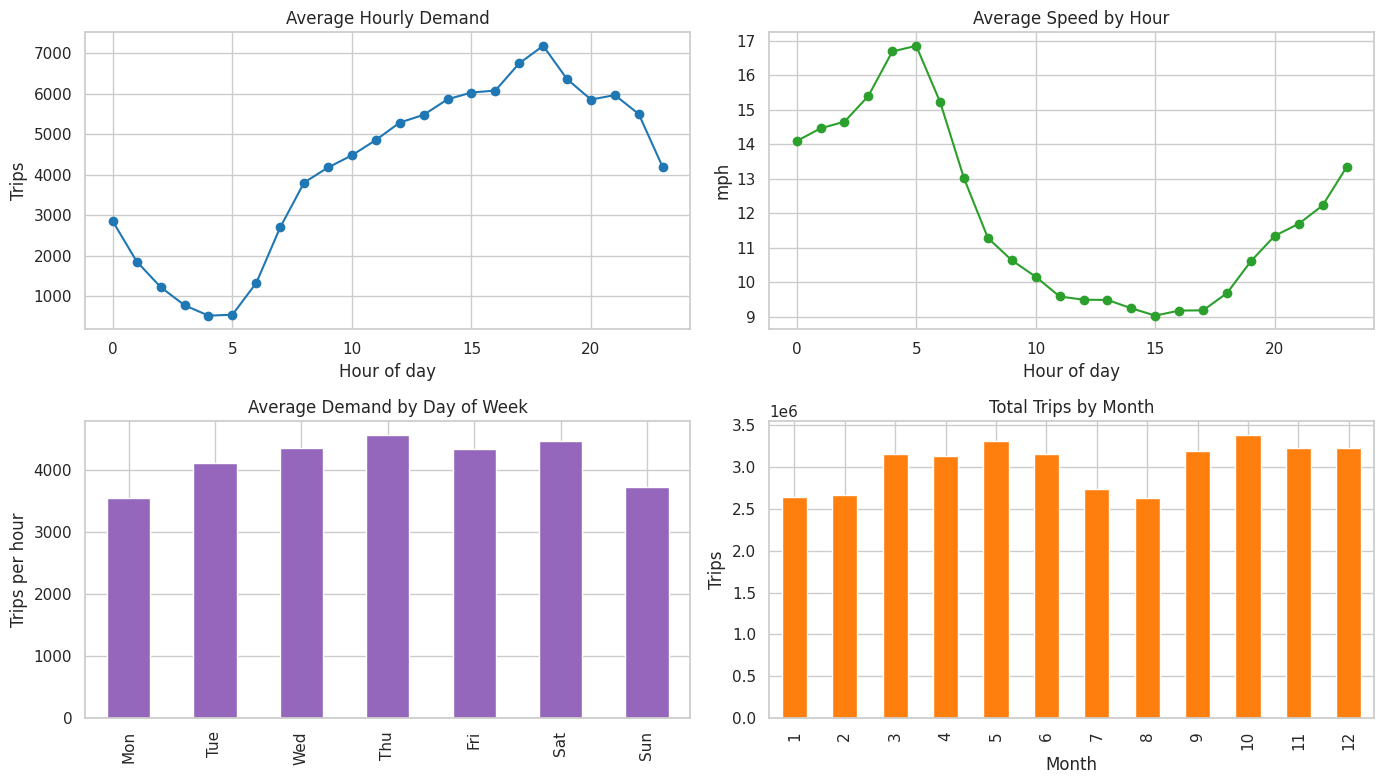

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

hourly_profile["mean_trip_count"].plot(ax=axes[0, 0], marker="o", color="#1f77b4")
axes[0, 0].set_title("Average Hourly Demand")
axes[0, 0].set_xlabel("Hour of day")
axes[0, 0].set_ylabel("Trips")

hourly_profile["mean_speed"].plot(ax=axes[0, 1], marker="o", color="#2ca02c")
axes[0, 1].set_title("Average Speed by Hour")
axes[0, 1].set_xlabel("Hour of day")
axes[0, 1].set_ylabel("mph")

weekday_profile["mean_trip_count"].plot(ax=axes[1, 0], kind="bar", color="#9467bd")
axes[1, 0].set_title("Average Demand by Day of Week")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Trips per hour")

monthly_profile["total_trips"].plot(ax=axes[1, 1], kind="bar", color="#ff7f0e")
axes[1, 1].set_title("Total Trips by Month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Trips")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_profiles.png", dpi=160, bbox_inches="tight")
plt.show()


## Task 2: Temporal Feature Engineering and Machine Learning

The supervised problem is **one-hour-ahead demand estimation** for the whole taxi system. Features combine calendar variables, cyclic encodings, recent lags, weekly seasonality, rolling means, rolling volatility, and same-hour trip behavior aggregates.

Split strategy:
- Train: January-October 2024
- Validation: November 2024
- Final test: December 2024


In [5]:
def make_supervised(hourly_df):
    features = hourly_df.copy()
    features["hour"] = features.index.hour
    features["day_of_week"] = features.index.dayofweek
    features["month"] = features.index.month
    features["day_of_year"] = features.index.dayofyear
    features["week_of_year"] = features.index.isocalendar().week.astype(int)
    features["is_weekend"] = (features["day_of_week"] >= 5).astype(int)
    features["is_peak"] = features["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
    features["is_late_night"] = features["hour"].isin([0, 1, 2, 3, 4]).astype(int)

    for period, col in [(24, "hour"), (7, "day_of_week"), (12, "month"), (366, "day_of_year")]:
        features[f"{col}_sin"] = np.sin(2 * np.pi * features[col] / period)
        features[f"{col}_cos"] = np.cos(2 * np.pi * features[col] / period)

    for lag in [1, 2, 3, 24, 48, 72, 168]:
        features[f"lag_{lag}"] = features["trip_count"].shift(lag)

    for window in [3, 6, 24, 168]:
        shifted = features["trip_count"].shift(1)
        features[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        features[f"roll_std_{window}"] = shifted.rolling(window).std()

    return features.dropna()


supervised = make_supervised(hourly)
feature_cols = [col for col in supervised.columns if col != "trip_count"]

train = supervised[supervised.index < "2024-11-01"]
valid = supervised[(supervised.index >= "2024-11-01") & (supervised.index < "2024-12-01")]
test = supervised[supervised.index >= "2024-12-01"]

print(f"Train rows: {len(train):,}; validation rows: {len(valid):,}; test rows: {len(test):,}")
print(f"Number of engineered features: {len(feature_cols)}")


Train rows: 7,152; validation rows: 720; test rows: 744
Number of engineered features: 37


In [6]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_%": np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100,
        "R2": r2_score(y_true, y_pred),
    }


model_specs = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=350, learning_rate=0.04, max_leaf_nodes=31,
        l2_regularization=0.05, random_state=42,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=250, min_samples_leaf=3, max_features=0.8,
        n_jobs=-1, random_state=42,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300, min_samples_leaf=2, max_features=0.85,
        n_jobs=-1, random_state=42,
    ),
}

rows = []
for split_name, split_df in [("Validation", valid), ("Test", test)]:
    metrics = regression_metrics(split_df["trip_count"], split_df["lag_168"])
    rows.append({"Model": "Seasonal naive lag_168", "Split": split_name, **metrics})

fitted_models = {}
for name, model in model_specs.items():
    model.fit(train[feature_cols], train["trip_count"])
    fitted_models[name] = model
    for split_name, split_df in [("Validation", valid), ("Test", test)]:
        pred = model.predict(split_df[feature_cols])
        rows.append({"Model": name, "Split": split_name, **regression_metrics(split_df["trip_count"], pred)})

model_results = pd.DataFrame(rows)
display(model_results.round(4))

validation_ranking = (
    model_results[model_results["Split"] == "Validation"]
    .sort_values(["MAPE_%", "RMSE"])
    .reset_index(drop=True)
)
print("Validation ranking")
display(validation_ranking.round(4))


,Model,Split,MAE,RMSE,MAPE_%,R2
0,Seasonal naive lag_168,Validation,701.1167,1143.3184,23.6602,0.8035
1,Seasonal naive lag_168,Test,1050.3965,1632.1401,36.2252,0.6449
2,Ridge,Validation,363.5031,510.6896,16.5447,0.9608
3,Ridge,Test,449.6469,583.5033,24.1122,0.9546
4,HistGradientBoosting,Validation,261.7636,391.3635,10.1704,0.9770
5,HistGradientBoosting,Test,311.1030,436.8090,12.6579,0.9746
6,RandomForest,Validation,281.5525,428.4046,10.6163,0.9724
7,RandomForest,Test,337.5224,488.1958,13.1329,0.9682
8,ExtraTrees,Validation,249.0119,382.1821,8.8020,0.9780
9,ExtraTrees,Test,314.3160,452.0322,11.0793,0.9728


Validation ranking


,Model,Split,MAE,RMSE,MAPE_%,R2
0,ExtraTrees,Validation,249.0119,382.1821,8.8020,0.9780
1,HistGradientBoosting,Validation,261.7636,391.3635,10.1704,0.9770
2,RandomForest,Validation,281.5525,428.4046,10.6163,0.9724
3,Ridge,Validation,363.5031,510.6896,16.5447,0.9608
4,Seasonal naive lag_168,Validation,701.1167,1143.3184,23.6602,0.8035


ExtraTrees is selected because it gives the best validation MAPE while remaining stable and fast on the hourly feature table. The final check refits on January-November and evaluates on untouched December data across several random seeds.


In [7]:
train_full = supervised[supervised.index < "2024-12-01"]
seeds = [7, 21, 42, 84, 168]
stability_rows = []

final_params = dict(
    n_estimators=500,
    min_samples_leaf=2,
    max_features=0.85,
    n_jobs=-1,
)

final_predictions = {}
final_models = {}

for seed in seeds:
    model = ExtraTreesRegressor(random_state=seed, **final_params)
    model.fit(train_full[feature_cols], train_full["trip_count"])
    pred = model.predict(test[feature_cols])
    final_predictions[seed] = pred
    final_models[seed] = model
    stability_rows.append({"Seed": seed, **regression_metrics(test["trip_count"], pred)})

stability_results = pd.DataFrame(stability_rows)
stability_summary = stability_results.drop(columns=["Seed"]).agg(["mean", "std"])

display(stability_results.round(4))
print("Stability summary across seeds")
display(stability_summary.round(4))

best_seed = int(stability_results.sort_values(["MAPE_%", "RMSE"]).iloc[0]["Seed"])
final_model = final_models[best_seed]
final_test_pred = final_predictions[best_seed]
final_metrics = regression_metrics(test["trip_count"], final_test_pred)

print(f"Selected seed for plots: {best_seed}")
print({key: round(value, 4) for key, value in final_metrics.items()})


,Seed,MAE,RMSE,MAPE_%,R2
0,7,282.4877,409.9888,9.6691,0.9776
1,21,281.0917,408.0692,9.6009,0.9778
2,42,281.8658,410.8363,9.6726,0.9775
3,84,282.0190,408.9670,9.6854,0.9777
4,168,282.6203,409.0640,9.6730,0.9777


Stability summary across seeds


,MAE,RMSE,MAPE_%,R2
mean,282.0169,409.3851,9.6602,0.9777
std,0.6051,1.0583,0.0337,0.0001


Selected seed for plots: 21
{'MAE': 281.0917, 'RMSE': 408.0692, 'MAPE_%': np.float64(9.6009), 'R2': 0.9778}


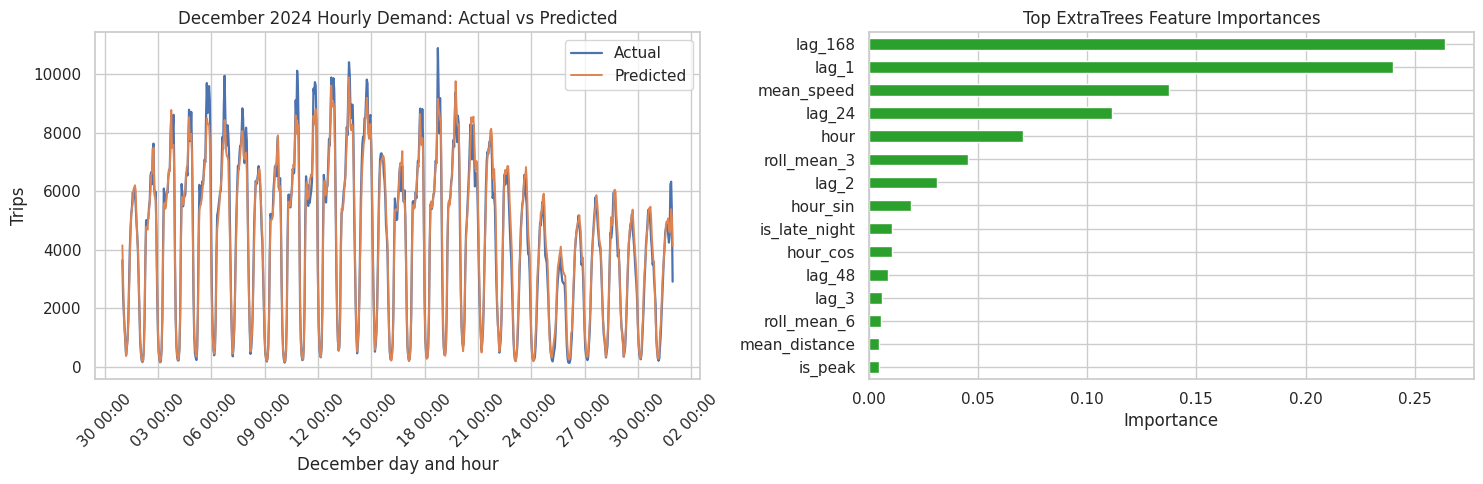

In [8]:
importance = (
    pd.Series(final_model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(test.index, test["trip_count"], label="Actual", linewidth=1.6)
axes[0].plot(test.index, final_test_pred, label="Predicted", linewidth=1.4)
axes[0].set_title("December 2024 Hourly Demand: Actual vs Predicted")
axes[0].set_ylabel("Trips")
axes[0].set_xlabel("December day and hour")
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %H:%M"))
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

importance.sort_values().plot(ax=axes[1], kind="barh", color="#2ca02c")
axes[1].set_title("Top ExtraTrees Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task2_forecast_and_importance.png", dpi=160, bbox_inches="tight")
plt.show()


## Task 4: Temporal Data Mining by Sequence Mining

Each hour is converted into a discrete temporal state using two interpretable signals:
- Demand bucket: low, medium, or high hourly trip count.
- Speed bucket: slow, normal, or fast hourly mean speed.

Daily 24-hour state sequences are then mined for frequent contiguous 2-state and 3-state patterns. This captures recurring temporal regimes such as late-night low-demand fast-flow periods and peak high-demand slow-flow periods.


,state,hours,share_%
0,LOW_DEMAND|FAST,2736,31.15
1,HIGH_DEMAND|SLOW,1852,21.08
2,MED_DEMAND|NORMAL_SPEED,1603,18.25
3,HIGH_DEMAND|NORMAL_SPEED,1132,12.89
4,MED_DEMAND|SLOW,1047,11.92
5,MED_DEMAND|FAST,247,2.81
6,LOW_DEMAND|NORMAL_SPEED,163,1.86
7,HIGH_DEMAND|FAST,4,0.05


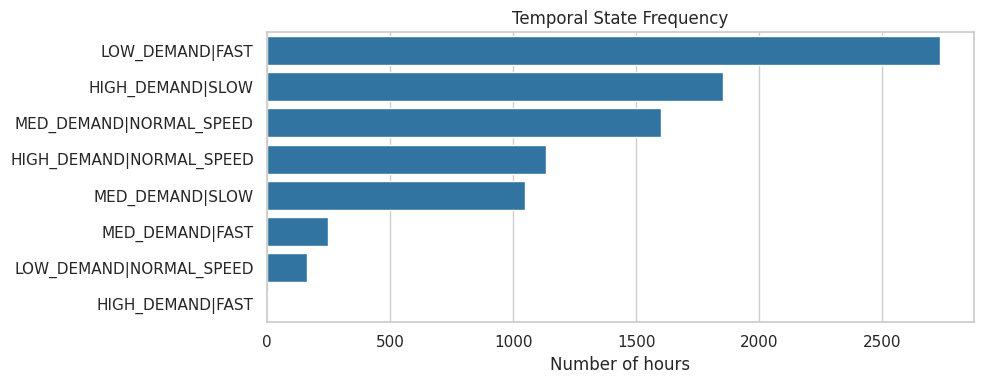

In [9]:
states = hourly.copy()
demand_quantiles = states["trip_count"].quantile([0.33, 0.66]).to_numpy()
speed_quantiles = states["mean_speed"].quantile([0.33, 0.66]).to_numpy()

states["demand_state"] = np.select(
    [states["trip_count"] < demand_quantiles[0], states["trip_count"] < demand_quantiles[1]],
    ["LOW_DEMAND", "MED_DEMAND"],
    default="HIGH_DEMAND",
)
states["speed_state"] = np.select(
    [states["mean_speed"] < speed_quantiles[0], states["mean_speed"] < speed_quantiles[1]],
    ["SLOW", "NORMAL_SPEED"],
    default="FAST",
)
states["state"] = states["demand_state"] + "|" + states["speed_state"]

state_counts = states["state"].value_counts().rename_axis("state").reset_index(name="hours")
state_counts["share_%"] = state_counts["hours"] / len(states) * 100
display(state_counts.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=state_counts, y="state", x="hours", ax=ax, color="#1f77b4")
ax.set_title("Temporal State Frequency")
ax.set_xlabel("Number of hours")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task4_state_frequency.png", dpi=160, bbox_inches="tight")
plt.show()


In [10]:
def daily_sequences(state_df):
    sequences = []
    for day, group in state_df.groupby(state_df.index.date):
        ordered = group.sort_index()
        if len(ordered) == 24:
            sequences.append((pd.Timestamp(day), list(ordered["state"])))
    return sequences


def mine_contiguous_ngrams(sequences, n):
    counts = Counter()
    total = 0
    for _, seq in sequences:
        for i in range(len(seq) - n + 1):
            counts[tuple(seq[i : i + n])] += 1
            total += 1
    return counts, total


sequences = daily_sequences(states)
pair_counts, pair_total = mine_contiguous_ngrams(sequences, 2)
triple_counts, triple_total = mine_contiguous_ngrams(sequences, 3)

antecedent_counts = Counter()
consequent_counts = Counter()
for (a, b), count in pair_counts.items():
    antecedent_counts[a] += count
    consequent_counts[b] += count

pair_rows = []
for (a, b), count in pair_counts.items():
    support = count / pair_total
    confidence = count / antecedent_counts[a]
    consequent_prob = consequent_counts[b] / pair_total
    lift = confidence / consequent_prob
    pair_rows.append({
        "Antecedent": a,
        "Consequent": b,
        "Count": count,
        "Support_%": support * 100,
        "Confidence_%": confidence * 100,
        "Lift": lift,
    })

sequence_rules = pd.DataFrame(pair_rows).sort_values(
    ["Confidence_%", "Support_%"], ascending=False
)
frequent_rules = sequence_rules[sequence_rules["Count"] >= 50].reset_index(drop=True)

triple_rows = [
    {
        "Sequence": " -> ".join(sequence),
        "Count": count,
        "Support_%": count / triple_total * 100,
    }
    for sequence, count in triple_counts.items()
]
frequent_triples = (
    pd.DataFrame(triple_rows)
    .sort_values(["Count", "Support_%"], ascending=False)
    .reset_index(drop=True)
)

print(f"Daily sequences mined: {len(sequences)}")
print("Top frequent 2-state rules with at least 50 occurrences")
display(frequent_rules.head(12).round(3))
print("Top frequent 3-state contiguous sequences")
display(frequent_triples.head(12).round(3))


Daily sequences mined: 366
Top frequent 2-state rules with at least 50 occurrences


,Antecedent,Consequent,Count,Support_%,Confidence_%,Lift
0,LOW_DEMAND|FAST,LOW_DEMAND|FAST,2233,26.526,85.885,2.888
1,HIGH_DEMAND|SLOW,HIGH_DEMAND|SLOW,1513,17.973,82.005,3.729
2,MED_DEMAND|SLOW,MED_DEMAND|SLOW,767,9.111,73.257,5.890
3,HIGH_DEMAND|NORMAL_SPEED,HIGH_DEMAND|NORMAL_SPEED,697,8.280,67.408,5.303
4,MED_DEMAND|NORMAL_SPEED,MED_DEMAND|NORMAL_SPEED,893,10.608,58.176,3.149
5,MED_DEMAND|FAST,LOW_DEMAND|FAST,103,1.224,53.093,1.786
6,LOW_DEMAND|NORMAL_SPEED,MED_DEMAND|NORMAL_SPEED,75,0.891,47.170,2.554
7,MED_DEMAND|FAST,MED_DEMAND|FAST,59,0.701,30.412,11.131
8,HIGH_DEMAND|NORMAL_SPEED,MED_DEMAND|NORMAL_SPEED,233,2.768,22.534,1.220
9,MED_DEMAND|SLOW,HIGH_DEMAND|SLOW,221,2.625,21.108,0.960


Top frequent 3-state contiguous sequences


,Sequence,Count,Support_%
0,LOW_DEMAND|FAST -> LOW_DEMAND|FAST -> LOW_DEMA...,1831,22.740
1,HIGH_DEMAND|SLOW -> HIGH_DEMAND|SLOW -> HIGH_D...,1221,15.164
2,MED_DEMAND|SLOW -> MED_DEMAND|SLOW -> MED_DEMA...,543,6.744
3,MED_DEMAND|NORMAL_SPEED -> MED_DEMAND|NORMAL_S...,528,6.557
4,HIGH_DEMAND|NORMAL_SPEED -> HIGH_DEMAND|NORMAL...,402,4.993
5,LOW_DEMAND|FAST -> LOW_DEMAND|FAST -> MED_DEMA...,244,3.030
6,HIGH_DEMAND|SLOW -> HIGH_DEMAND|SLOW -> HIGH_D...,227,2.819
7,HIGH_DEMAND|SLOW -> HIGH_DEMAND|NORMAL_SPEED -...,202,2.509
8,MED_DEMAND|SLOW -> HIGH_DEMAND|SLOW -> HIGH_DE...,201,2.496
9,MED_DEMAND|SLOW -> MED_DEMAND|SLOW -> HIGH_DEM...,189,2.347


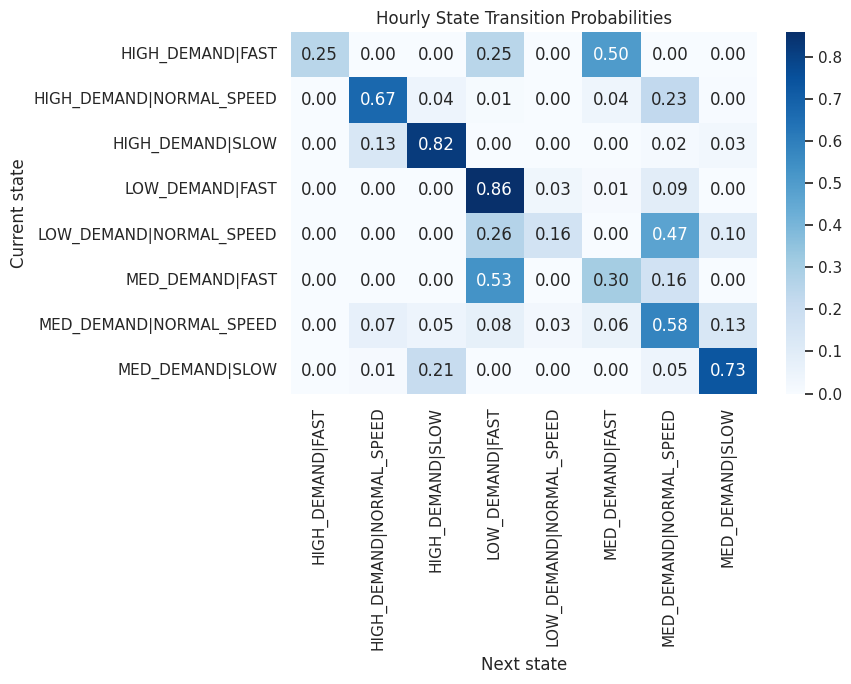

In [11]:
all_states = sorted(states["state"].unique())
transition_matrix = pd.DataFrame(0, index=all_states, columns=all_states, dtype=float)
for (a, b), count in pair_counts.items():
    transition_matrix.loc[a, b] = count
transition_probs = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(transition_probs, cmap="Blues", annot=True, fmt=".2f", ax=ax)
ax.set_title("Hourly State Transition Probabilities")
ax.set_xlabel("Next state")
ax.set_ylabel("Current state")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task4_transition_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


In [12]:
train_sequences = [(day, seq) for day, seq in sequences if day < pd.Timestamp("2024-11-01")]
holdout_sequences = [(day, seq) for day, seq in sequences if day >= pd.Timestamp("2024-11-01")]

transition_counts = defaultdict(Counter)
state_frequency = Counter()
for _, seq in train_sequences:
    state_frequency.update(seq)
    for current_state, next_state in zip(seq, seq[1:]):
        transition_counts[current_state][next_state] += 1

majority_state = state_frequency.most_common(1)[0][0]

correct_markov = 0
correct_majority = 0
total_transitions = 0

for _, seq in holdout_sequences:
    for current_state, next_state in zip(seq, seq[1:]):
        if transition_counts[current_state]:
            predicted = transition_counts[current_state].most_common(1)[0][0]
        else:
            predicted = majority_state
        correct_markov += predicted == next_state
        correct_majority += majority_state == next_state
        total_transitions += 1

markov_results = pd.DataFrame([
    {
        "Model": "First-order Markov transition rule",
        "Holdout": "Nov-Dec 2024",
        "Transitions": total_transitions,
        "Accuracy_%": correct_markov / total_transitions * 100,
    },
    {
        "Model": "Majority-state baseline",
        "Holdout": "Nov-Dec 2024",
        "Transitions": total_transitions,
        "Accuracy_%": correct_majority / total_transitions * 100,
    },
])
display(markov_results.round(3))


,Model,Holdout,Transitions,Accuracy_%
0,First-order Markov transition rule,Nov-Dec 2024,1403,75.695
1,Majority-state baseline,Nov-Dec 2024,1403,29.294


## Main Findings for Report

- Hourly demand is highly structured by time of day and day of week, so lag features, rolling windows, and cyclic calendar encodings are appropriate for Task 2.
- The best forecasting model is ExtraTrees after validation-based selection. It strongly improves over the weekly seasonal naive baseline on December 2024.
- Task 4 sequence mining shows that the strongest transitions are persistent states: low-demand fast-flow hours tend to be followed by similar hours, and high-demand slow-flow hours also persist.
- The Markov holdout result confirms that temporal state transitions are not random; learned transition rules substantially outperform a majority-state baseline.


In [13]:
best_validation_row = validation_ranking.iloc[0]
final_mean = stability_summary.loc["mean"]
final_std = stability_summary.loc["std"]
top_rule = frequent_rules.iloc[0]
top_triple = frequent_triples.iloc[0]
markov_acc = markov_results.loc[
    markov_results["Model"] == "First-order Markov transition rule", "Accuracy_%"
].iloc[0]
majority_acc = markov_results.loc[
    markov_results["Model"] == "Majority-state baseline", "Accuracy_%"
].iloc[0]

summary_text = f"""Task 2 and Task 4 Summary

Dataset used: cleaned 2024 NYC TLC Yellow Taxi trips from dataset/clean_*.parquet.
Temporal aggregation: {len(hourly):,} hourly rows covering 2024.

Task 2 - Temporal ML:
Engineered calendar, cyclic, lag, rolling-window, and hourly behavior features. Validation selected ExtraTrees as the best model. After refitting on Jan-Nov and testing on Dec, five random-seed runs produced mean MAE {final_mean['MAE']:.2f}, mean RMSE {final_mean['RMSE']:.2f}, mean MAPE {final_mean['MAPE_%']:.2f}%, and mean R2 {final_mean['R2']:.4f}. The run-to-run R2 std was {final_std['R2']:.6f}, so the result is stable. The weekly naive baseline had much worse December MAPE ({model_results[(model_results['Model'] == 'Seasonal naive lag_168') & (model_results['Split'] == 'Test')]['MAPE_%'].iloc[0]:.2f}%).

Task 4 - Temporal Data Mining:
Each hour was discretized into demand-speed states and daily 24-hour sequences were mined. The strongest frequent rule was {top_rule['Antecedent']} -> {top_rule['Consequent']} with {top_rule['Count']} occurrences, {top_rule['Confidence_%']:.2f}% confidence, and lift {top_rule['Lift']:.2f}. The most frequent 3-state sequence was {top_triple['Sequence']} with {top_triple['Count']} occurrences. A Markov next-state model trained on Jan-Oct reached {markov_acc:.2f}% accuracy on Nov-Dec transitions versus {majority_acc:.2f}% for the majority-state baseline.
"""

summary_text = "\n".join(line.strip() for line in summary_text.strip().splitlines())
Path("task2_task4_auto_metrics_summary.txt").write_text(summary_text)
print(summary_text)


Task 2 and Task 4 Summary

Dataset used: cleaned 2024 NYC TLC Yellow Taxi trips from dataset/clean_*.parquet.
Temporal aggregation: 8,784 hourly rows covering 2024.

Task 2 - Temporal ML:
Engineered calendar, cyclic, lag, rolling-window, and hourly behavior features. Validation selected ExtraTrees as the best model. After refitting on Jan-Nov and testing on Dec, five random-seed runs produced mean MAE 282.02, mean RMSE 409.39, mean MAPE 9.66%, and mean R2 0.9777. The run-to-run R2 std was 0.000116, so the result is stable. The weekly naive baseline had much worse December MAPE (36.23%).

Task 4 - Temporal Data Mining:
Each hour was discretized into demand-speed states and daily 24-hour sequences were mined. The strongest frequent rule was LOW_DEMAND|FAST -> LOW_DEMAND|FAST with 2233 occurrences, 85.88% confidence, and lift 2.89. The most frequent 3-state sequence was LOW_DEMAND|FAST -> LOW_DEMAND|FAST -> LOW_DEMAND|FAST with 1831 occurrences. A Markov next-state model trained on Jan-Oc